# InsightX AI — 01: Data Exploration

Exploratory analysis of the cleaned business data stored in PostgreSQL.
Every chart in this notebook is built to answer a specific business question — not just to look nice.

In [7]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.database.db_connection import get_engine

sns.set_style("whitegrid")
engine = get_engine()

orders = pd.read_sql("SELECT * FROM orders WHERE status = 'Delivered'", engine)
customers = pd.read_sql("SELECT * FROM customers", engine)
products = pd.read_sql("SELECT * FROM products", engine)
reviews = pd.read_sql("SELECT * FROM reviews", engine)

orders["order_date"] = pd.to_datetime(orders["order_date"])
print(f"Orders: {len(orders)} | Customers: {len(customers)} | Products: {len(products)} | Reviews: {len(reviews)}")

Orders: 5202 | Customers: 1500 | Products: 60 | Reviews: 2081


## 1. Missing values sanity check
Confirms Phase 5's cleaning held up — should show all zeros or very close to it.

In [8]:
print("Orders missing values:\n", orders.isnull().sum())
print("\nCustomers missing values:\n", customers.isnull().sum())

Orders missing values:
 order_id          0
customer_id       0
product_id        0
order_date        0
quantity          0
price             0
discount          0
payment_method    0
delivery_time     0
status            0
revenue           0
dtype: int64

Customers missing values:
 customer_id         0
customer_name       0
age                 0
gender              0
city                0
signup_date         0
customer_segment    0
tenure_days         0
dtype: int64


## 2. Revenue distribution
**Business question:** What does a typical order look like? Is spend concentrated or spread out?

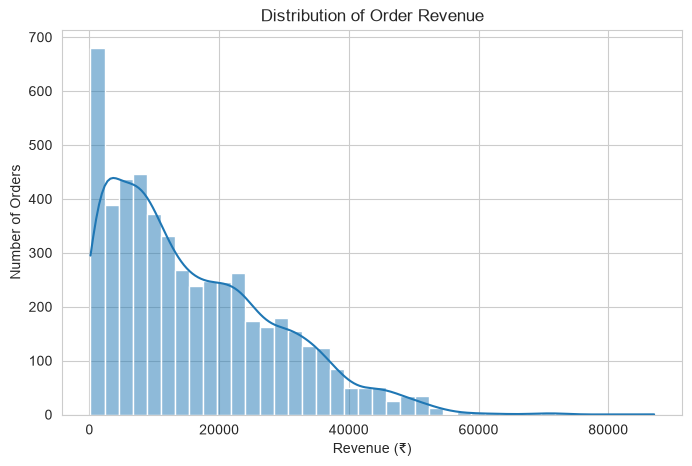

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(orders["revenue"], bins=40, kde=True)
plt.title("Distribution of Order Revenue")
plt.xlabel("Revenue (\u20b9)")
plt.ylabel("Number of Orders")
plt.show()

## 3. Outlier check
**Business question:** Are there unusually extreme orders worth investigating?

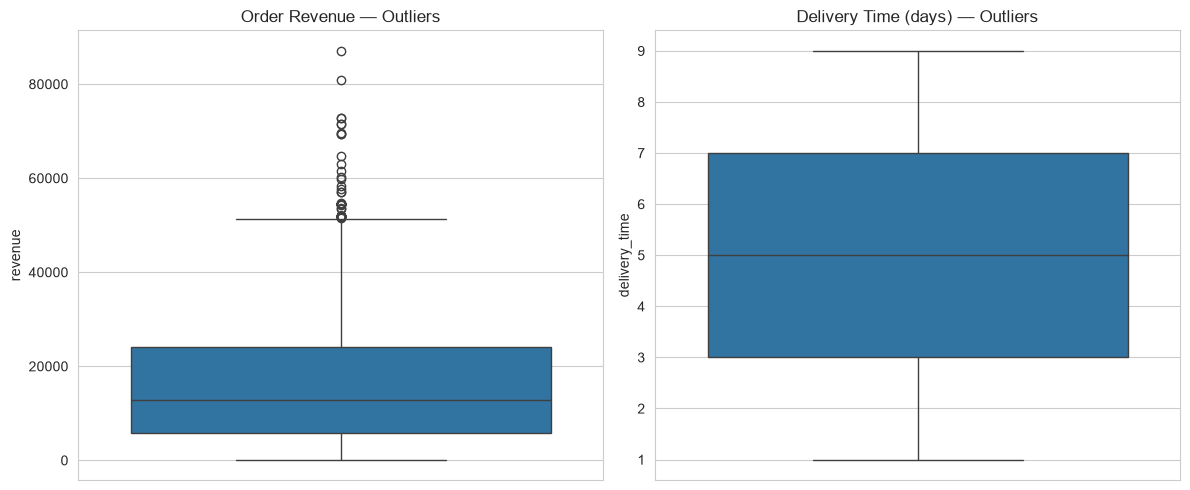

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(y=orders["revenue"], ax=axes[0])
axes[0].set_title("Order Revenue — Outliers")
sns.boxplot(y=orders["delivery_time"], ax=axes[1])
axes[1].set_title("Delivery Time (days) — Outliers")
plt.tight_layout()
plt.show()

## 4. Correlation heatmap
**Business question:** Which numeric factors move together? This informs feature selection for the churn model in Phase 10.

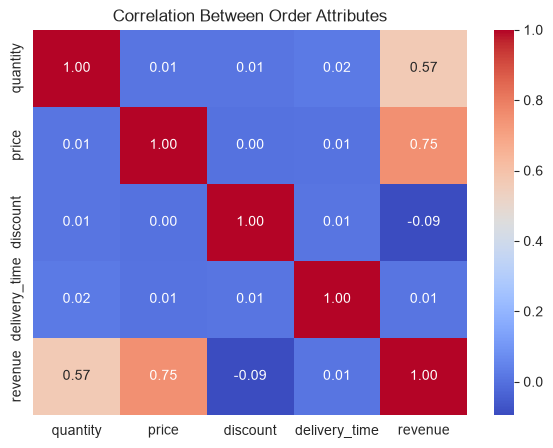

In [11]:
numeric_cols = orders[["quantity", "price", "discount", "delivery_time", "revenue"]]
plt.figure(figsize=(7,5))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Order Attributes")
plt.show()

## 5. Monthly revenue trend
**Business question:** Is the business growing, flat, or shrinking? Are there unusual months? (Watch for the injected anomaly month from Phase 3.)

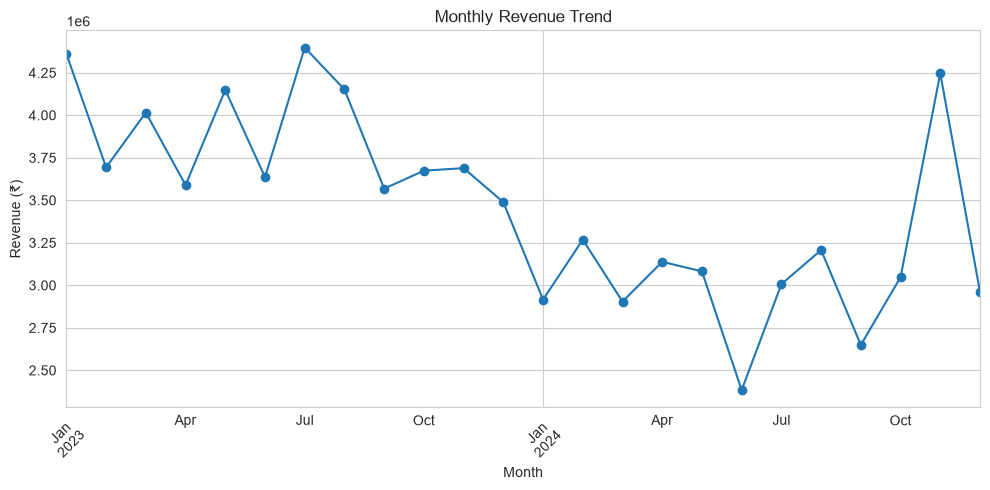

In [12]:
monthly_revenue = orders.groupby(orders["order_date"].dt.to_period("M"))["revenue"].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (\u20b9)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Orders per customer
**Business question:** Do a few customers drive most orders, or is behavior evenly spread? (Previews RFM segmentation in Phase 9.)

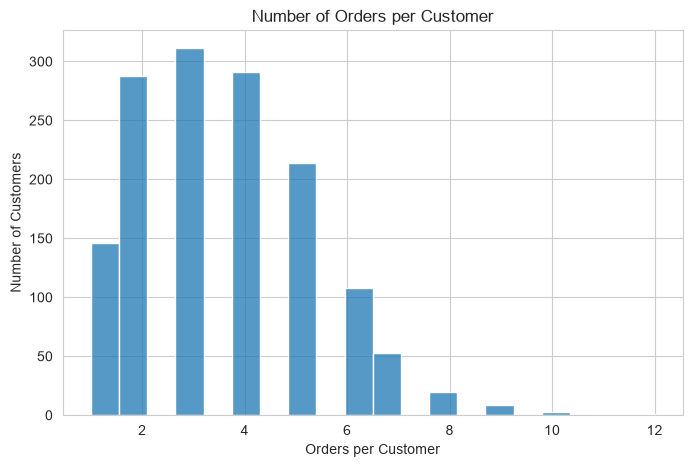

count    1445.000000
mean        3.600000
std         1.752481
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        12.000000
dtype: float64


In [13]:
orders_per_customer = orders.groupby("customer_id").size()

plt.figure(figsize=(8,5))
sns.histplot(orders_per_customer, bins=20)
plt.title("Number of Orders per Customer")
plt.xlabel("Orders per Customer")
plt.ylabel("Number of Customers")
plt.show()

print(orders_per_customer.describe())

## 7. Revenue by product category
**Business question:** Which product categories matter most to the business?

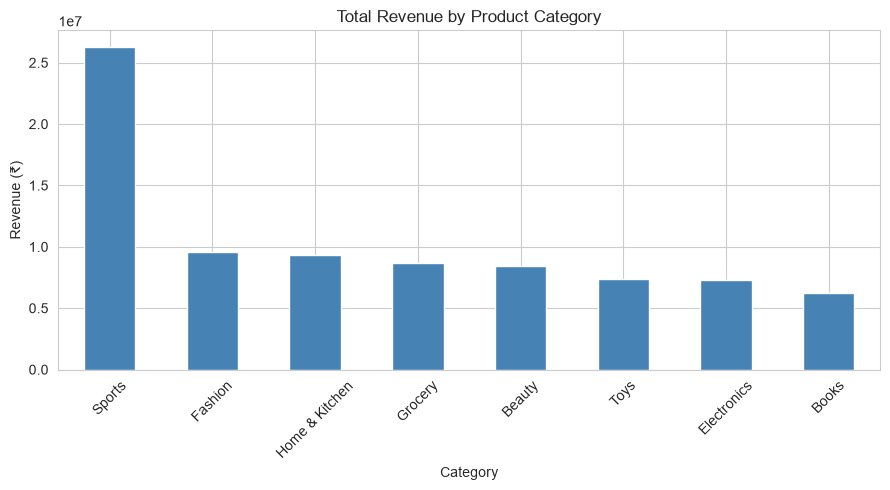

In [14]:
orders_products = orders.merge(products, on="product_id")
category_revenue = orders_products.groupby("category")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(9,5))
category_revenue.plot(kind="bar", color="steelblue")
plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (\u20b9)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Revenue by city
**Business question:** Which regions matter most, and are any cities underperforming relative to their customer base?

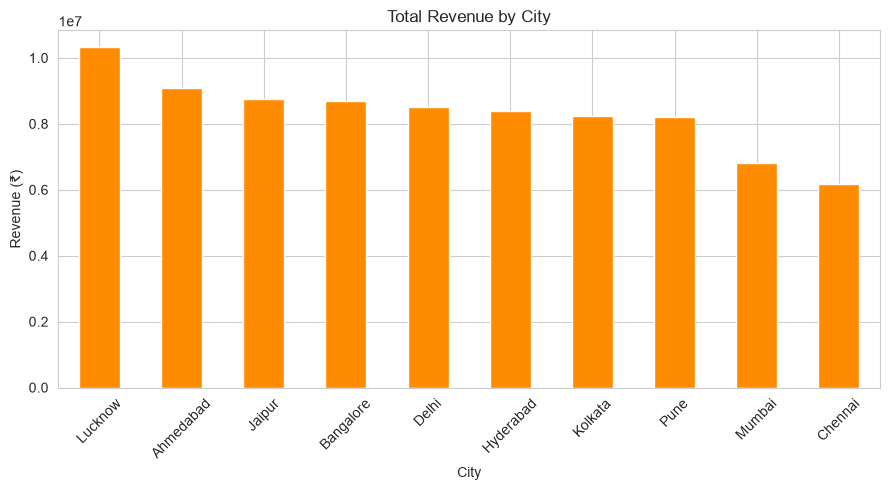

In [15]:
orders_customers = orders.merge(customers, on="customer_id")
city_revenue = orders_customers.groupby("city")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(9,5))
city_revenue.plot(kind="bar", color="darkorange")
plt.title("Total Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue (\u20b9)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Summary of findings

_Fill this in after running the notebook — write 4-5 bullet points in your own words:_
- Which category and city led revenue?
CATEGORY: Sports   CITY:Lucknow
- Did you spot the anomaly month in the trend chart?
- What did the correlation heatmap reveal (or not reveal)?
- Is order behavior concentrated among a few customers or spread evenly?

These findings will directly feed into Phase 9 (RFM/customer analytics).